In [ ]:
import os
import time
from pathlib import Path
import argparse
import numpy as np
def sanitize_path(path):
    """确保路径是绝对路径并规范化"""
    return Path(os.path.abspath(path))

# 输入参数
stl_path = "/home/chenguisen/AISI/nebula/data/4_Trench Milling.stl"  # STL文件路径
output_path = "output"  # 输出目录路径

stl_path = sanitize_path(stl_path)
output_path = sanitize_path(output_path)
tri_dir = output_path
tri_dir.mkdir(parents=True, exist_ok=True)
# 保留原始文件名
name = stl_path.stem

import pyvista as pv
import torch
mesh = pv.read(stl_path)
mesh = mesh.rotate_x(-55, point=(0,0,0), inplace=False)
points = torch.tensor(mesh.points, dtype=torch.float32)  # 显式转换为PyTorch张量
print(points)
points_ = torch.stack([points[:, 0], points[:, 1], points[:, 2]], dim=1)
print(points_)
faces = mesh.faces        # 扁平化数组，需解析
faces = faces.reshape(-1, 4)[:, 1:]  # 转换为 (m, 3)
print("faces:", faces)
# for face in faces:
#     print(face)
#     print(face.shape)
#     print(points[face.item(),0], points[face.item(),1], points[face.item(),2])
pv.plot(mesh)

/home/chenguisen/miniconda3/envs/cstool-env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


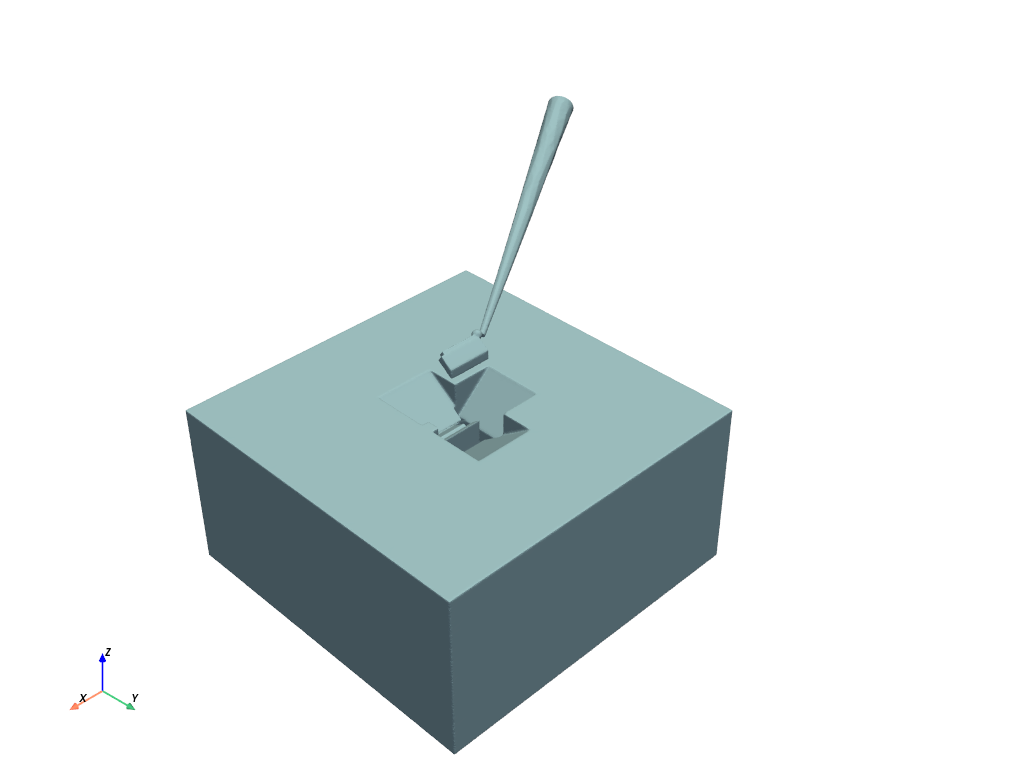

/home/chenguisen/miniconda3/envs/cstool-env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


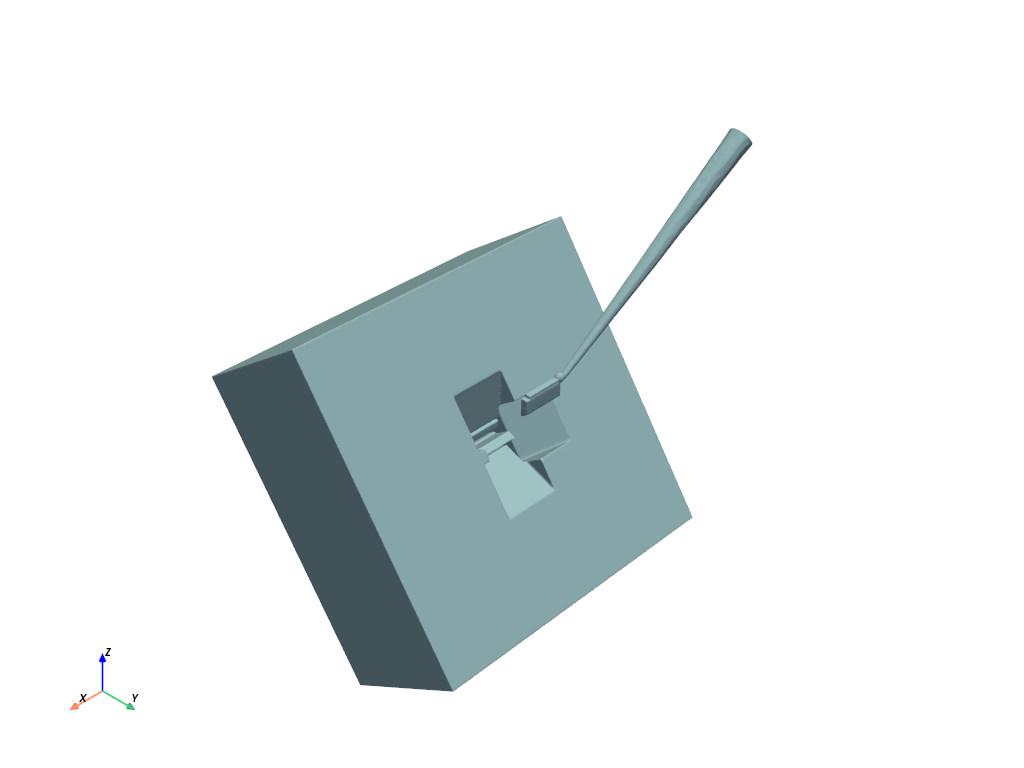

In [12]:
# tilt stl file

import pyvista as pv

# 读取STL文件
import os
stl_path = os.path.join("/home/chenguisen/AISI/nebula/simulation_results/output_04.stl")
mesh = pv.read(stl_path)

# 可视化
pv.plot(mesh)
# 旋转模型
mesh = mesh.rotate_x(-55, point=(0,0,0), inplace=False)
mesh.save(stl_path)  # 保存旋转后的STL文件


# 可视化
pv.plot(mesh)